# Comparison of HLT vs Prompt Calibration for di-Electron Mass

In [27]:
import uproot
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np

In [21]:
HLT_GT_path = "DQM_V0001_HLT_R000398858_HLT_GT.root"
PROMPT_path = "DQM_V0001_HLT_R000398858_PROMPT.root"
files = {
    "HLT (online calibration)":     HLT_GT_path,
    "Prompt (offline calibration)": PROMPT_path,
}

/tmp/ipykernel_62405/411089405.py:34: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.cms.label(ax=ax, data=True, label="Preliminary", com=13.6)


(60.0, 120.0)

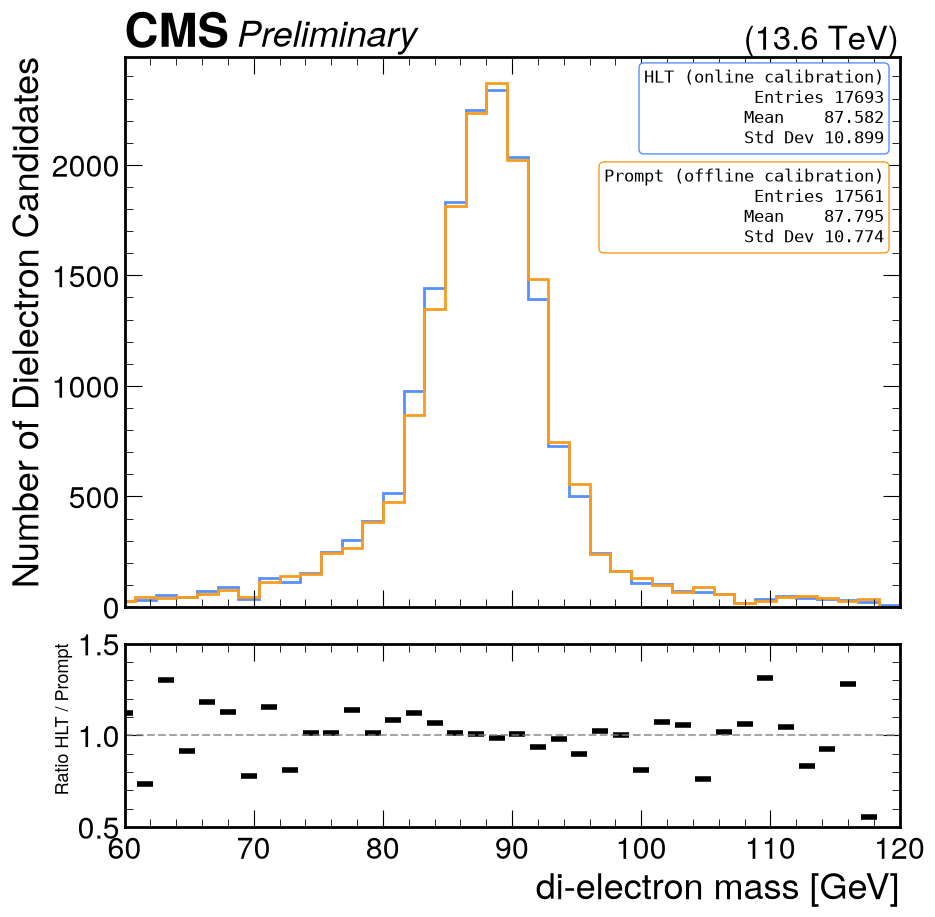

In [40]:
plt.style.use(hep.style.CMS)
fig, (ax, ax_ratio) = plt.subplots(
    2, 1, figsize=(10, 10), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.1},
)

# search in root file for "di-Electron_Mass"
hist_name = "di-Electron_Mass"
stored = {}
colors = ["C0", "C1"]

for i, ((label, path), color) in enumerate(zip(files.items(), colors)):
    with uproot.open(path) as f:
        key = next(k for k in f.keys() if hist_name in k)
        h = f[key]
    counts, edges = h.to_numpy()
    stored[label] = (counts, color)
    hep.histplot(counts, edges, label=label, histtype="step", linewidth=2, color=color, ax=ax)

    sw      = h.member("fTsumw")
    mean    = h.member("fTsumwx")  / sw
    std     = (h.member("fTsumwx2") / sw - mean**2) ** 0.5
    entries = h.member("fEntries")

    box = f"{label}\nEntries {entries:.0f}\nMean    {mean:.3f}\nStd Dev {std:.3f}"
    ax.text(0.98, 0.98 - i*0.18, box, transform=ax.transAxes,
            ha="right", va="top", family="monospace", fontsize=12,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor=color))



#ax.set_xlabel("di-electron mass [GeV]")
ax.set_ylabel("Number of Dielectron Candidates")
hep.cms.label(ax=ax, data=True, label="Preliminary", com=13.6)

ref_label = next(l for l in stored if "Prompt" in l)   # Prompt = denominator
num_label = next(l for l in stored if l != ref_label)
ref, _        = stored[ref_label]
num, num_col  = stored[num_label]

centers = 0.5 * (edges[:-1] + edges[1:])
ratio = np.divide(num, ref, out=np.full_like(num, np.nan), where=ref > 0)

ax_ratio.plot(centers, ratio, "_", color="black", markersize=12, markeredgewidth=4)
ax_ratio.axhline(1.0, color="gray", linestyle="--", alpha=0.7)
ax_ratio.set_ylabel(f"Ratio HLT / Prompt", fontsize=13)
ax_ratio.set_xlabel("di-electron mass [GeV]")
ax_ratio.set_ylim(0.5, 1.5)
ax.set_xlim(60, 120)     

In [41]:
fig.savefig("di_electron_mass.png", bbox_inches="tight")